# 04 Gradient Boosting Regressor

This notebook builds and evaluates a Gradient Boosting model for predicting used car selling prices. Gradient Boosting is an ensemble method that sequentially builds weak decision trees, where each new tree is trained to correct the residual errors of the previous ones.

**How it works:**
1. Make an initial prediction for all rows (e.g., the mean price).
2. Calculate the residuals -- the gap between predictions and actual values.
3. Train a small decision tree to predict those residuals.
4. Add the tree's predictions to the running model, scaled by a learning rate.
5. Repeat, with each iteration reducing the remaining error.

The learning rate controls how aggressively each tree contributes, trading off speed for stability.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)

## Data Loading and Split

Same split methodology as the baseline notebook: 80/20, `random_state=42`, full feature set. This ensures an apples-to-apples comparison.

In [9]:
df = pd.read_csv('data/cleaned/car_prices_cleaned.csv')

X = df.drop('sellingprice', axis=1)
y = df['sellingprice']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

print(f"Training set: {X_train.shape[0]:,} samples")
print(f"Test set:     {X_test.shape[0]:,} samples")
print(f"Features:     {X_train.shape[1]}")
print(f"\nAverage selling price: ${y.mean():,.2f}")

Training set: 436,346 samples
Test set:     109,087 samples
Features:     919

Average selling price: $13,725.53


## Baseline Recap

Before training our model, recall the baseline results from notebook 03. These are loaded automatically from `data/baseline_results.json` (saved by notebook 03).

In [10]:
import json

with open('data/baseline_results.json', 'r') as f:
    baseline_data = json.load(f)

baselines = pd.DataFrame([
    {'Model': name, 'MAE ($)': vals['MAE'], 'R²': vals['R2']}
    for name, vals in baseline_data.items()
]).set_index('Model').sort_values('MAE ($)')

print("Baseline results (from notebook 03):")
baselines

Baseline results (from notebook 03):


,MAE ($),R²
Model,,
Random Forest,954.36,0.9712
Lasso Regression,968.98,0.9704
Ridge Regression,969.70,0.9705
Linear Regression,969.87,0.9704


## Model Training

**Hyperparameters:**
- `n_estimators=100`: number of boosting stages (trees)
- `learning_rate=0.1`: how much each tree contributes
- `max_depth=20`: maximum depth per tree
- `min_samples_split=5`: minimum samples to create a new branch
- `min_samples_leaf=3`: minimum samples required in each leaf node
- `max_features=0.6`: fraction of features considered at each split
- `loss='huber'`: robust to outliers (combines squared and absolute error)

In [11]:
model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=3,
    max_features=0.6,
    loss='huber',
    random_state=42
)

model.fit(X_train, y_train)
print("Model training complete.")

Model training complete.


## Performance Metrics

In [12]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
test_rmse = root_mean_squared_error(y_test, y_test_pred)

print(f"{'':25s} {'MAE ($)':>12s}   {'R²':>8s}")
print(f"{'─' * 50}")
print(f"{'Training Set':25s} {train_mae:>12,.2f}   {train_r2:>8.4f}")
print(f"{'Test Set':25s} {test_mae:>12,.2f}   {test_r2:>8.4f}")
print(f"\nTest RMSE: ${test_rmse:,.2f}")
print(f"Average selling price: ${y.mean():,.2f}")
print(f"Test MAE as % of avg price: {(test_mae / y.mean()) * 100:.1f}%")

                               MAE ($)         R²
──────────────────────────────────────────────────
Training Set                    417.91     0.9937
Test Set                        898.34     0.9731

Average selling price: $13,725.53
Test MAE as % of avg price: 6.5%


## Baseline Comparison Table

In [13]:
gb_row = pd.DataFrame([{'Model': 'Gradient Boosting', 'MAE ($)': round(test_mae, 2), 'R²': round(test_r2, 4)}]).set_index('Model')
comparison = pd.concat([baselines, gb_row]).sort_values('MAE ($)')

print("Model Comparison (Test Set):")
comparison

Model Comparison (Test Set):


,MAE ($),R²
Model,,
Gradient Boosting,898.34,0.9731
Random Forest,954.36,0.9712
Lasso Regression,968.98,0.9704
Ridge Regression,969.70,0.9705
Linear Regression,969.87,0.9704


## Feature Importance

Which features does the model rely on most to make predictions?

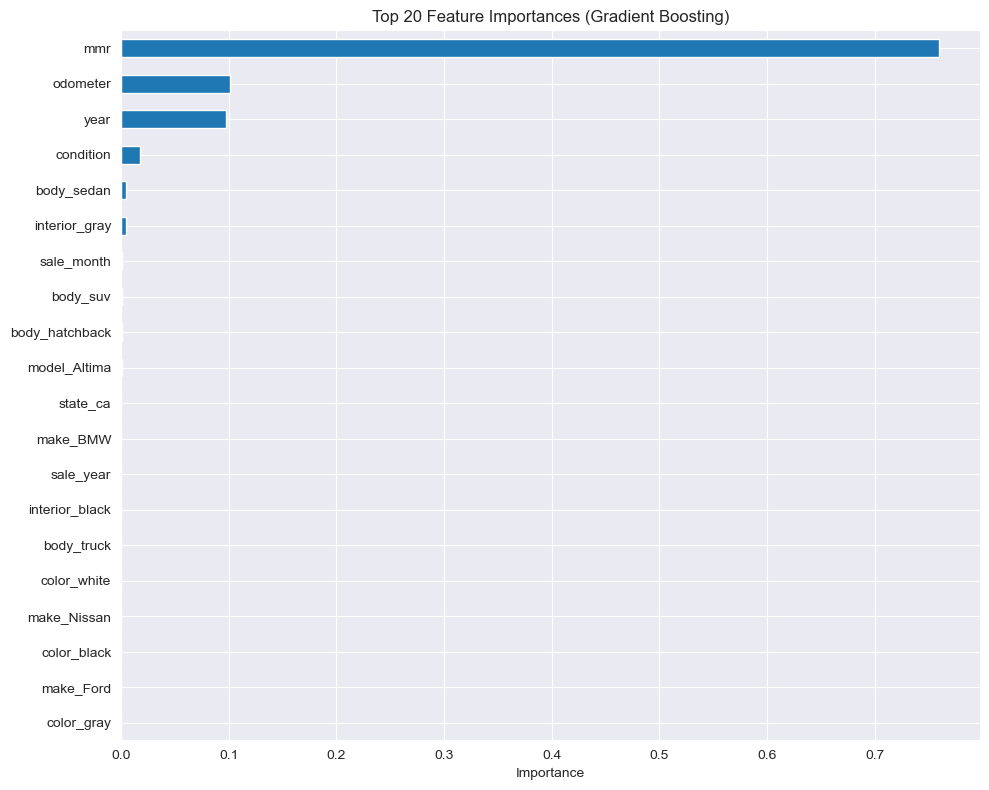


Top 5 features account for 98.1% of total importance.


In [14]:
importances = pd.Series(model.feature_importances_, index=X.columns)
top_20 = importances.nlargest(20)

plt.figure(figsize=(10, 8))
top_20.sort_values().plot(kind='barh')
plt.title('Top 20 Feature Importances (Gradient Boosting)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print(f"\nTop 5 features account for {top_20.head(5).sum() / importances.sum() * 100:.1f}% of total importance.")

In [ ]:
print("Top 5 features by importance:", top_20.head(5).index.tolist())
print("\nTop 10:")
for i, (name, imp) in enumerate(top_20.head(10).items(), 1):
    print(f"  {i}. {name}: {imp:.4f}")

## Error Analysis

Understanding where the model gets it wrong is as important as knowing the overall accuracy. We examine the residual distribution and look for systematic errors across price and mileage segments.

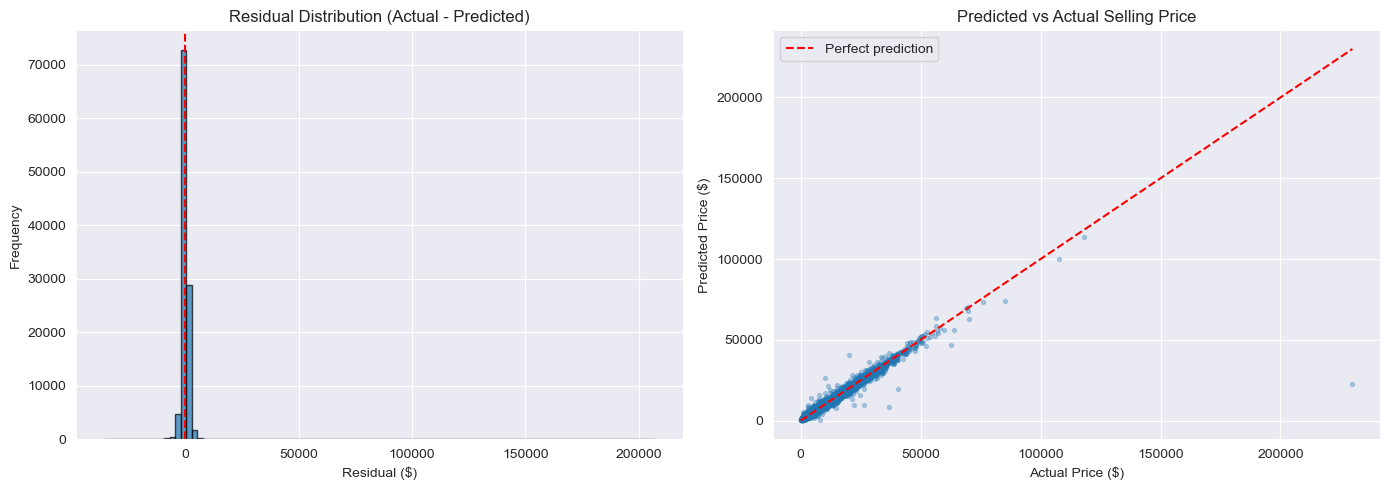

In [15]:
residuals = y_test.values - y_test_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(residuals, bins=100, edgecolor='black', alpha=0.7)
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_title('Residual Distribution (Actual - Predicted)')
axes[0].set_xlabel('Residual ($)')
axes[0].set_ylabel('Frequency')

sample_idx = np.random.RandomState(42).choice(len(y_test), size=5000, replace=False)
axes[1].scatter(y_test.values[sample_idx], y_test_pred[sample_idx], alpha=0.3, s=8)
max_val = max(y_test.values[sample_idx].max(), y_test_pred[sample_idx].max())
axes[1].plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Perfect prediction')
axes[1].set_title('Predicted vs Actual Selling Price')
axes[1].set_xlabel('Actual Price ($)')
axes[1].set_ylabel('Predicted Price ($)')
axes[1].legend()

plt.tight_layout()
plt.show()

### Error by Price Segment

Does the model struggle more with certain price ranges?

In [16]:
error_df = pd.DataFrame({
    'actual': y_test.values,
    'predicted': y_test_pred,
    'abs_error': np.abs(residuals),
    'odometer': X_test['odometer'].values
})

price_bins = [0, 5000, 10000, 20000, 30000, 50000, np.inf]
price_labels = ['$0-5k', '$5-10k', '$10-20k', '$20-30k', '$30-50k', '$50k+']
error_df['price_segment'] = pd.cut(error_df['actual'], bins=price_bins, labels=price_labels)

segment_errors = error_df.groupby('price_segment', observed=False).agg(
    count=('abs_error', 'count'),
    mean_abs_error=('abs_error', 'mean'),
    median_abs_error=('abs_error', 'median')
).round(2)

print("MAE by Price Segment:")
segment_errors

MAE by Price Segment:


,count,mean_abs_error,median_abs_error
price_segment,,,
$0-5k,19738,696.50,486.02
$5-10k,21374,850.53,621.27
$10-20k,45827,800.05,534.63
$20-30k,16266,1112.97,784.43
$30-50k,5220,1682.36,1135.31
$50k+,662,3808.14,2229.41


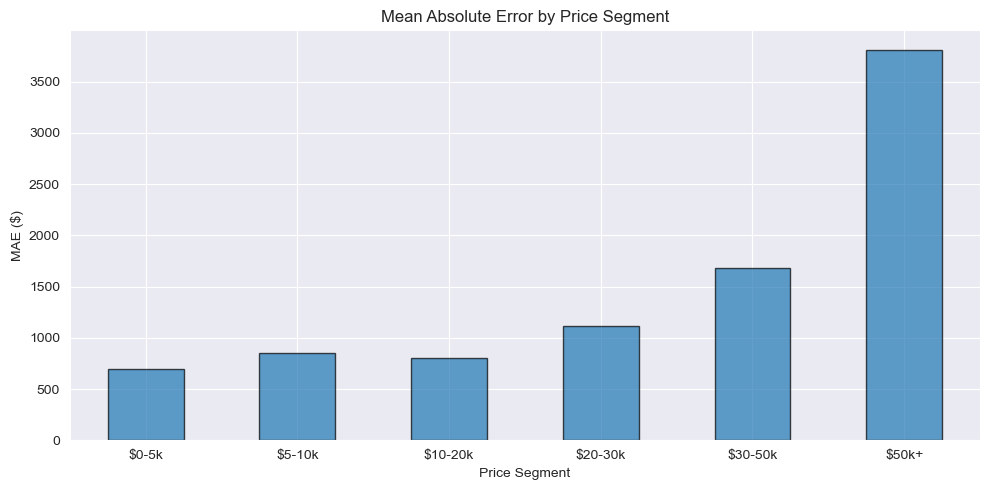

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
segment_errors['mean_abs_error'].plot(kind='bar', ax=ax, edgecolor='black', alpha=0.7)
ax.set_title('Mean Absolute Error by Price Segment')
ax.set_xlabel('Price Segment')
ax.set_ylabel('MAE ($)')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

### Error by Mileage Segment

Does prediction accuracy degrade for high-mileage vehicles?

In [18]:
mileage_bins = [0, 25000, 50000, 75000, 100000, 150000, np.inf]
mileage_labels = ['0-25k', '25-50k', '50-75k', '75-100k', '100-150k', '150k+']
error_df['mileage_segment'] = pd.cut(error_df['odometer'], bins=mileage_bins, labels=mileage_labels)

mileage_errors = error_df.groupby('mileage_segment', observed=False).agg(
    count=('abs_error', 'count'),
    mean_abs_error=('abs_error', 'mean'),
    median_abs_error=('abs_error', 'median')
).round(2)

print("MAE by Mileage Segment:")
mileage_errors

MAE by Mileage Segment:


,count,mean_abs_error,median_abs_error
mileage_segment,,,
0-25k,23573,1041.84,597.69
25-50k,30273,886.28,577.54
50-75k,16798,866.30,590.96
75-100k,12458,966.72,729.92
100-150k,17246,824.76,614.43
150k+,8739,662.34,446.24


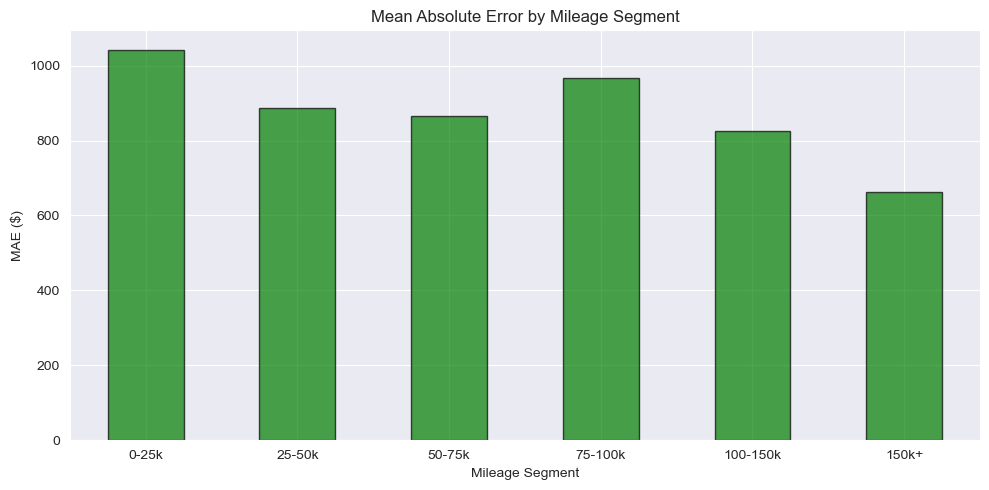

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))
mileage_errors['mean_abs_error'].plot(kind='bar', ax=ax, color='green', edgecolor='black', alpha=0.7)
ax.set_title('Mean Absolute Error by Mileage Segment')
ax.set_xlabel('Mileage Segment')
ax.set_ylabel('MAE ($)')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

## Conclusion

The Gradient Boosting model reduces prediction error compared to the baseline models, achieving the lowest MAE and highest R² on the held-out test set. The feature importance analysis reveals that MMR, odometer, year, and condition are the dominant predictors, with the remaining ~900 one-hot encoded features contributing incrementally.

The error analysis shows that the model performs best in the $5k-$30k range where most of the data lives, and struggles more with high-end vehicles ($50k+) where training examples are sparse. The gap between training MAE and test MAE suggests some degree of overfitting -- potential next steps include reducing `max_depth`, increasing `n_estimators` with a lower learning rate, or applying cross-validation for hyperparameter tuning.

Overall, the model predicts used car auction prices within a few percent of the average selling price, making it a practical tool for price estimation.